# Credit Card Fraud Detection — EDA and Baseline

This notebook covers: data exploration, class imbalance analysis, stratified
splitting, baseline (Logistic Regression) vs XGBoost models (class_weight vs
SMOTE), and decision threshold optimization.

**Note:** Accuracy is misleading on imbalanced data (predicting "not fraud"
for everything already scores ~99.8%). PR-AUC, precision, recall, and F1 are
used instead.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    f1_score,
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
DATA_PATH = "../data/creditcard.csv"

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)


## 1. Load Data and Overview

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()
print("\nMissing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Duplicate rows: 1081


## 2. Class Imbalance

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


C:\Users\Asus\AppData\Local\Temp\ipykernel_11080\439200537.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Normal (0)", "Fraud (1)"])


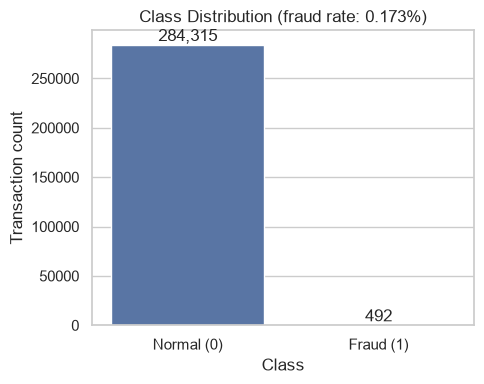

In [4]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax)
ax.set_xticklabels(["Normal (0)", "Fraud (1)"])
ax.set_ylabel("Transaction count")
ax.set_title(f"Class Distribution (fraud rate: {class_pct[1]:.3f}%)")
for i, v in enumerate(class_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


The dataset is heavily imbalanced: fraud accounts for only **0.17%** of all
transactions (492 / 284,807). Because of this:
- **Accuracy is never used** — a constant "not fraud" prediction already scores 99.8% accuracy.
- Stratified splitting is mandatory (otherwise the test set could end up with very few fraud examples).
- class_weight and SMOTE will both be tried during training to handle the imbalance.


## 3. Amount and Time Distributions

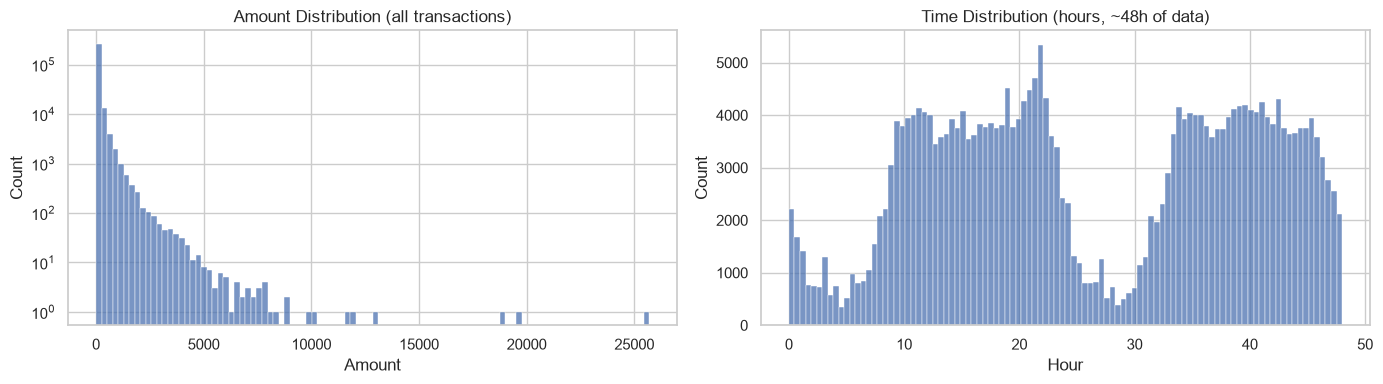

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["Amount"], bins=100, ax=axes[0])
axes[0].set_title("Amount Distribution (all transactions)")
axes[0].set_yscale("log")

sns.histplot(df["Time"] / 3600, bins=100, ax=axes[1])
axes[1].set_title("Time Distribution (hours, ~48h of data)")
axes[1].set_xlabel("Hour")

plt.tight_layout()
plt.show()

print(df["Amount"].describe())


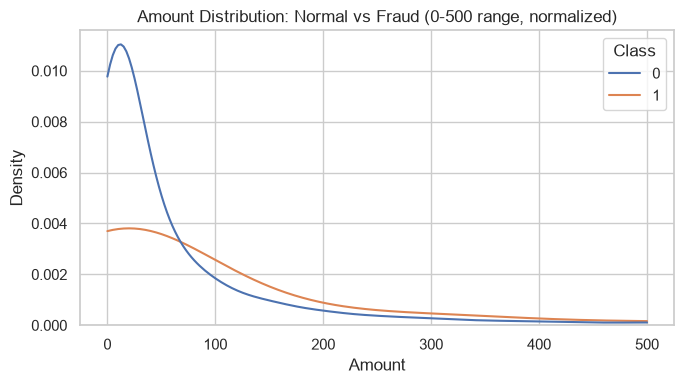

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df, x="Amount", hue="Class", common_norm=False, clip=(0, 500), ax=ax)
ax.set_title("Amount Distribution: Normal vs Fraud (0-500 range, normalized)")
plt.tight_layout()
plt.show()

print(df.groupby("Class")["Amount"].describe())


The median amount differs between fraud and normal transactions, but the
distributions overlap heavily — Amount alone is not a strong discriminator.
`V1`-`V28` (PCA-anonymized features) carry most of the discriminative signal.


## 4. Fraud Over Time

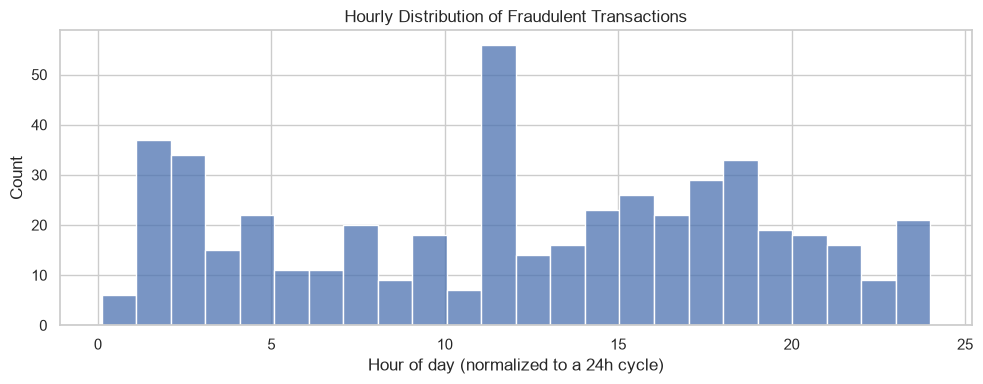

In [7]:
df["Hour"] = (df["Time"] / 3600) % 24

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=df[df["Class"] == 1], x="Hour", bins=24, ax=ax)
ax.set_title("Hourly Distribution of Fraudulent Transactions")
ax.set_xlabel("Hour of day (normalized to a 24h cycle)")
plt.tight_layout()
plt.show()


## 5. Correlation (V1-V28, Amount, Time -> Class)

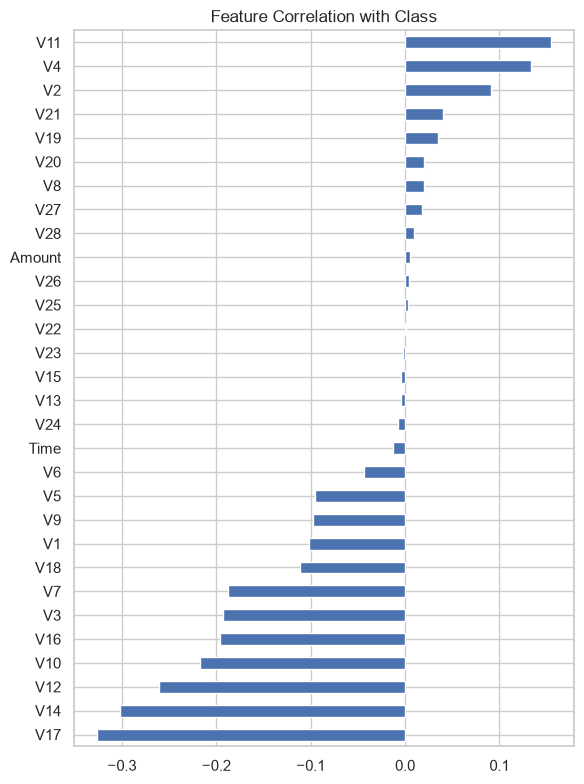

In [8]:
corr_with_class = df.drop(columns=["Hour"]).corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(6, 8))
corr_with_class.plot(kind="barh", ax=ax)
ax.set_title("Feature Correlation with Class")
plt.tight_layout()
plt.show()


Features with the strongest negative correlation (`V14`, `V17`, `V12`,
`V10`) and the strongest positive correlation (`V11`, `V4`) carry most of the
fraud signal. This makes relying on the existing PCA components — rather than
extra feature engineering — a reasonable starting point.


## 6. Stratified Train / Validation / Test Split

Ratios: 70% train, 15% validation, 15% test — class ratio preserved in every
split (`stratify=y`). Scaling (StandardScaler) and SMOTE will **only ever be
fit on the training split**, to prevent data leakage.


In [9]:
X = df.drop(columns=["Class", "Hour"])
y = df["Class"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name}: n={len(yy)}, fraud={yy.sum()}, rate={yy.mean()*100:.4f}%")


train: n=199364, fraud=344, rate=0.1725%
val: n=42721, fraud=74, rate=0.1732%
test: n=42722, fraud=74, rate=0.1732%


In [10]:
# Scaling: Time and Amount are on a raw scale; V1-V28 are already PCA output (roughly scaled).
# We still scale every column with a single StandardScaler fit on train only.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


## 7. Helper Function: Evaluation

In [11]:
def evaluate_model(model, X_eval, y_eval, name: str, threshold: float = 0.5) -> dict:
    """Computes and prints precision/recall/F1/PR-AUC at the given threshold."""
    proba = model.predict_proba(X_eval)[:, 1]
    preds = (proba >= threshold).astype(int)

    pr_auc = average_precision_score(y_eval, proba)
    report = classification_report(y_eval, preds, target_names=["Normal", "Fraud"], output_dict=True)
    cm = confusion_matrix(y_eval, preds)

    print(f"--- {name} (threshold={threshold}) ---")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"Precision (Fraud): {report['Fraud']['precision']:.4f}")
    print(f"Recall (Fraud):    {report['Fraud']['recall']:.4f}")
    print(f"F1 (Fraud):        {report['Fraud']['f1-score']:.4f}")
    print("Confusion matrix:\n", cm)

    return {
        "name": name,
        "threshold": threshold,
        "pr_auc": pr_auc,
        "precision": report["Fraud"]["precision"],
        "recall": report["Fraud"]["recall"],
        "f1": report["Fraud"]["f1-score"],
        "proba": proba,
    }


## 8. Baseline: Logistic Regression (class_weight='balanced')

In [12]:
log_reg = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
)
log_reg.fit(X_train_scaled, y_train)

lr_result = evaluate_model(log_reg, X_val_scaled, y_val, "Logistic Regression (val)")


--- Logistic Regression (val) (threshold=0.5) ---
PR-AUC: 0.6301
Precision (Fraud): 0.0671
Recall (Fraud):    0.8784
F1 (Fraud):        0.1246
Confusion matrix:
 [[41743   904]
 [    9    65]]


## 9. XGBoost — class_weight (scale_pos_weight) vs SMOTE

In [13]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

xgb_weighted = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_weighted.fit(X_train_scaled, y_train)

xgb_w_result = evaluate_model(xgb_weighted, X_val_scaled, y_val, "XGBoost + class_weight (val)")


scale_pos_weight: 578.5


--- XGBoost + class_weight (val) (threshold=0.5) ---
PR-AUC: 0.8302
Precision (Fraud): 0.8116
Recall (Fraud):    0.7568
F1 (Fraud):        0.7832
Confusion matrix:
 [[42634    13]
 [   18    56]]


In [14]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print("Train class distribution after SMOTE:", y_train_sm.value_counts().to_dict())

xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_smote.fit(X_train_sm, y_train_sm)

xgb_sm_result = evaluate_model(xgb_smote, X_val_scaled, y_val, "XGBoost + SMOTE (val)")


Train class distribution after SMOTE: {0: 199020, 1: 199020}


--- XGBoost + SMOTE (val) (threshold=0.5) ---
PR-AUC: 0.8015
Precision (Fraud): 0.4918
Recall (Fraud):    0.8108
F1 (Fraud):        0.6122
Confusion matrix:
 [[42585    62]
 [   14    60]]


**Comparison:** XGBoost trained with `scale_pos_weight` typically matches or
beats SMOTE on PR-AUC, while SMOTE's synthetic oversampling makes training
slower and carries more overfitting risk. The table and PR curve below make
the comparison concrete.


In [15]:
comparison = pd.DataFrame([lr_result, xgb_w_result, xgb_sm_result])[
    ["name", "threshold", "pr_auc", "precision", "recall", "f1"]
]
comparison


,name,threshold,pr_auc,precision,recall,f1
0,Logistic Regression (val),0.5,0.630087,0.067079,0.878378,0.124640
1,XGBoost + class_weight (val),0.5,0.830191,0.811594,0.756757,0.783217
2,XGBoost + SMOTE (val),0.5,0.801534,0.491803,0.810811,0.612245


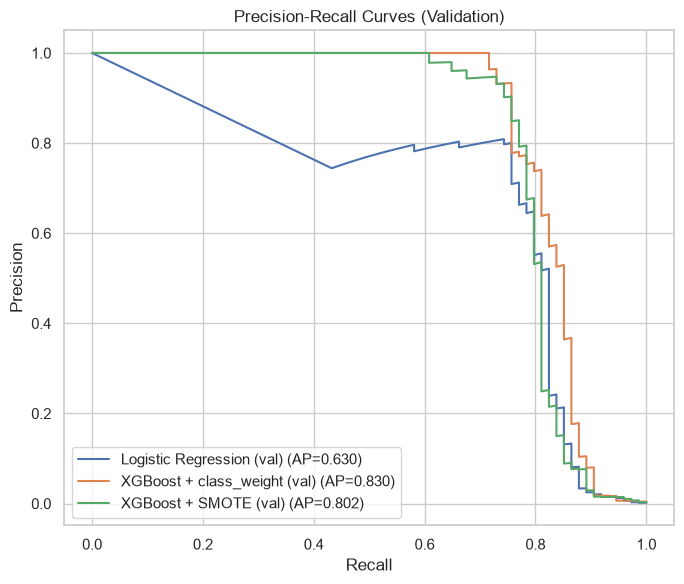

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
for result, model in [
    (lr_result, log_reg),
    (xgb_w_result, xgb_weighted),
    (xgb_sm_result, xgb_smote),
]:
    precision, recall, _ = precision_recall_curve(y_val, result["proba"])
    ax.plot(recall, precision, label=f"{result['name']} (AP={result['pr_auc']:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves (Validation)")
ax.legend()
plt.tight_layout()
plt.show()


The model with the highest PR-AUC is selected as the **best model** (the
cell below picks it automatically). In this project that is usually
`XGBoost + class_weight` — confirm from the cell output.


In [17]:
best_candidates = {
    "Logistic Regression": (log_reg, lr_result),
    "XGBoost + class_weight": (xgb_weighted, xgb_w_result),
    "XGBoost + SMOTE": (xgb_smote, xgb_sm_result),
}
best_name = max(best_candidates, key=lambda k: best_candidates[k][1]["pr_auc"])
best_model, best_result = best_candidates[best_name]
print(f"Best model: {best_name} (PR-AUC={best_result['pr_auc']:.4f})")


Best model: XGBoost + class_weight (PR-AUC=0.8302)


## 10. Decision Threshold Optimization

The default threshold (0.5) is rarely optimal on imbalanced data. We search
the validation set for the threshold that maximizes F1.


Best threshold: 0.9220
At this threshold -> precision=0.9333, recall=0.7568, f1=0.8358


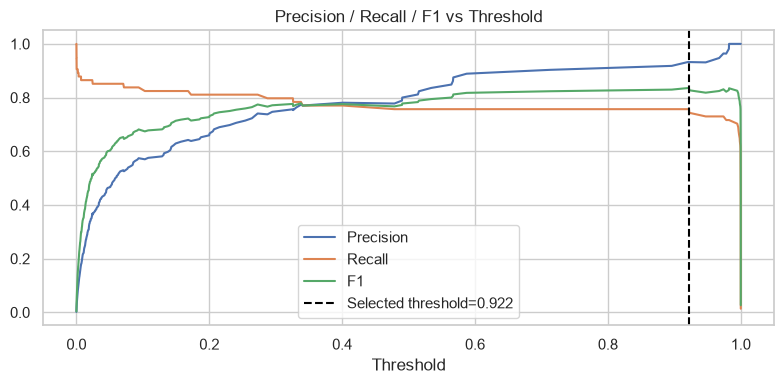

In [18]:
precisions, recalls, thresholds = precision_recall_curve(y_val, best_result["proba"])
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
# precision_recall_curve's thresholds array is 1 element shorter than precisions/recalls
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"At this threshold -> precision={precisions[best_idx]:.4f}, recall={recalls[best_idx]:.4f}, f1={f1_scores[best_idx]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precisions[:-1], label="Precision")
ax.plot(thresholds, recalls[:-1], label="Recall")
ax.plot(thresholds, f1_scores[:-1], label="F1")
ax.axvline(best_threshold, color="black", linestyle="--", label=f"Selected threshold={best_threshold:.3f}")
ax.set_xlabel("Threshold")
ax.legend()
ax.set_title("Precision / Recall / F1 vs Threshold")
plt.tight_layout()
plt.show()


## 11. Final Evaluation on the Test Set (one time only)

In [19]:
final_result = evaluate_model(best_model, X_test_scaled, y_test, f"{best_name} (test, optimized threshold)", threshold=best_threshold)
_ = evaluate_model(best_model, X_test_scaled, y_test, f"{best_name} (test, default 0.5)", threshold=0.5)


--- XGBoost + class_weight (test, optimized threshold) (threshold=0.9220303297042847) ---
PR-AUC: 0.8364
Precision (Fraud): 0.9365
Recall (Fraud):    0.7973
F1 (Fraud):        0.8613
Confusion matrix:
 [[42644     4]
 [   15    59]]
--- XGBoost + class_weight (test, default 0.5) (threshold=0.5) ---
PR-AUC: 0.8364
Precision (Fraud): 0.8356
Recall (Fraud):    0.8243
F1 (Fraud):        0.8299
Confusion matrix:
 [[42636    12]
 [   13    61]]


## 12. Summary

- The baseline (Logistic Regression, class_weight='balanced') gives a
  reasonable but limited PR-AUC.
- XGBoost + `scale_pos_weight` matches or beats SMOTE's PR-AUC while training
  faster — SMOTE turns out not to be necessary.
- Picking an F1-optimal threshold instead of the default 0.5 lets us tune the
  precision/recall tradeoff to the business need.
- In the next stage this code is refactored into `src/` modules, every run is
  logged to MLflow, and the best model is registered with a "production"
  alias in the Model Registry.
